# V2 — Pipeline sans leakage

**Fix critique** : normalisation fit sur le train **après** le split, jamais sur le val.

1. Sample équilibré (30%, classes 50/50)
2. Feature engineering
3. **Split avant normalisation**
4. RF + LightGBM + NN benchmark

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time
import json
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import lightgbm as lgb

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

Device : cpu


---
## Part 1 — Création du sample équilibré (30%)

In [19]:
X_full = pd.read_csv('Data/X_train.csv')
y_full = pd.read_csv('Data/y_train.csv')

print(f'X_train complet : {X_full.shape}')
y_full['target_SIGN'] = (y_full['target'] > 0).astype(int)
print(f'Distribution originale : {y_full["target_SIGN"].value_counts().to_dict()}')

X_train complet : (527073, 45)
Distribution originale : {1: 267323, 0: 259750}


In [20]:
total_n = len(y_full)
sample_n = int(total_n * 0.30)
n_per_class = sample_n // 2

idx_up = y_full[y_full['target_SIGN'] == 1].index.values
idx_down = y_full[y_full['target_SIGN'] == 0].index.values

sampled_up = np.random.choice(idx_up, size=n_per_class, replace=False)
sampled_down = np.random.choice(idx_down, size=n_per_class, replace=False)
sampled_idx = np.concatenate([sampled_up, sampled_down])
np.random.shuffle(sampled_idx)

X_sample = X_full.loc[sampled_idx].reset_index(drop=True)
y_sample = y_full.loc[sampled_idx, ['ROW_ID', 'target']].reset_index(drop=True)

X_sample.to_csv('Data/X_train_sample.csv', index=False)
y_sample.to_csv('Data/y_train_sample.csv', index=False)
print(f'✅ Sample sauvegardé : {X_sample.shape[0]:,} lignes (50/50 équilibré)')

✅ Sample sauvegardé : 158,120 lignes (50/50 équilibré)


---
## Part 2 — Feature Engineering

In [21]:
def feature_engineering(df):
    """
    Feature engineering appliqué par ligne (pas de leakage possible).
    Fonctionne sur train ET test.
    """
    data = df.copy()
    ret_cols = [f'RET_{i}' for i in range(1, 21)]
    
    data['RET_1_TURNOVER'] = data['RET_1'] * data['MEDIAN_DAILY_TURNOVER']
    data['RET_MEAN_5'] = data[[f'RET_{i}' for i in range(1, 6)]].mean(axis=1)
    data['RET_MEAN_20'] = data[ret_cols].mean(axis=1)
    data['RET_STD_5'] = data[[f'RET_{i}' for i in range(1, 6)]].std(axis=1)
    data['RET_STD_20'] = data[ret_cols].std(axis=1)
    data['RET_CUM_5'] = data[[f'RET_{i}' for i in range(1, 6)]].sum(axis=1)
    data['RET_CUM_20'] = data[ret_cols].sum(axis=1)
    data['RET_POSITIVE_COUNT_5'] = (data[[f'RET_{i}' for i in range(1, 6)]] > 0).sum(axis=1)
    data['RET_POSITIVE_COUNT_20'] = (data[ret_cols] > 0).sum(axis=1)
    data['RET_RECENT_VS_OLD'] = data['RET_MEAN_5'] - data[[f'RET_{i}' for i in range(16, 21)]].mean(axis=1)
    
    return data

print('Feature engineering function defined.')

Feature engineering function defined.


In [22]:
df = X_sample.merge(y_sample, on='ROW_ID')
df = feature_engineering(df)
df['target_SIGN'] = (df['target'] > 0).astype(int)

exclude_cols = ['ROW_ID', 'TS', 'ALLOCATION', 'target', 'target_SIGN']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X_all = df[feature_cols].fillna(0)
y_all = df['target_SIGN'].values

print(f'Dataset après FE : {X_all.shape}')
print(f'Features ({len(feature_cols)}) : {feature_cols}')

Dataset après FE : (158120, 52)
Features (52) : ['RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9', 'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1', 'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18', 'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15', 'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12', 'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9', 'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6', 'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3', 'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP', 'RET_1_TURNOVER', 'RET_MEAN_5', 'RET_MEAN_20', 'RET_STD_5', 'RET_STD_20', 'RET_CUM_5', 'RET_CUM_20', 'RET_POSITIVE_COUNT_5', 'RET_POSITIVE_COUNT_20', 'RET_RECENT_VS_OLD']


---
## Part 3 — Split AVANT normalisation (fix leakage)

**⚠️ Point critique** : on split d'abord, puis on fit les scalers sur le train UNIQUEMENT.

In [23]:
# 1. SPLIT AVANT NORMALISATION
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)

print(f'Train : {X_train_raw.shape[0]:,}')
print(f'Val   : {X_val_raw.shape[0]:,}')

Train : 126,496
Val   : 31,624


In [24]:
def normalize_by_group_fit(X_train_df, group_col='GROUP'):
    """
    Fit les scalers sur le TRAIN set uniquement.
    Retourne le train normalisé + les scalers.
    """
    X_norm = X_train_df.copy()
    numeric_cols = [c for c in X_norm.columns if c != group_col]
    scalers = {}
    
    for grp in X_norm[group_col].unique():
        mask = X_norm[group_col] == grp
        scaler = StandardScaler()
        X_norm.loc[mask, numeric_cols] = scaler.fit_transform(X_norm.loc[mask, numeric_cols])
        scalers[grp] = scaler
    
    return X_norm, scalers

def normalize_by_group_transform(X_df, scalers, group_col='GROUP'):
    """
    Transform avec les scalers du train (JAMAIS fit sur ces données).
    """
    X_norm = X_df.copy()
    numeric_cols = [c for c in X_norm.columns if c != group_col]
    
    for grp in X_norm[group_col].unique():
        mask = X_norm[group_col] == grp
        if grp in scalers:
            X_norm.loc[mask, numeric_cols] = scalers[grp].transform(X_norm.loc[mask, numeric_cols])
        else:
            # Groupe inconnu dans le train → fit_transform (fallback)
            scaler = StandardScaler()
            X_norm.loc[mask, numeric_cols] = scaler.fit_transform(X_norm.loc[mask, numeric_cols])
    
    return X_norm

# 2. FIT sur train, TRANSFORM sur val
X_train, train_scalers = normalize_by_group_fit(X_train_raw)
X_val = normalize_by_group_transform(X_val_raw, train_scalers)

print('✅ Normalisation sans leakage :')
print(f'  Scalers fit sur train uniquement ({X_train.shape[0]:,} lignes)')
print(f'  Val transformé avec les scalers du train ({X_val.shape[0]:,} lignes)')

# Sauvegarder les scalers et feature_cols pour submission.ipynb
import pickle
with open('train_scalers.pkl', 'wb') as f:
    pickle.dump({'scalers': train_scalers, 'feature_cols': feature_cols}, f)
print('  Scalers sauvegardés dans train_scalers.pkl')

# Convertir en numpy
X_train_np = X_train.values.astype(np.float32)
X_val_np = X_val.values.astype(np.float32)

✅ Normalisation sans leakage :
  Scalers fit sur train uniquement (126,496 lignes)
  Val transformé avec les scalers du train (31,624 lignes)
  Scalers sauvegardés dans train_scalers.pkl


---
## Part 4 — Random Forest

In [28]:
print('=== Random Forest ===')
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    {'n_estimators': [100],
     'max_depth': [15],
     'min_samples_split': [10],
     'min_samples_leaf': [5],
     'max_features': ['sqrt']},
    n_iter=15, cv=3, scoring='accuracy', random_state=SEED, n_jobs=-1
)
rf_search.fit(X_train_np, y_train)

rf_val_acc = accuracy_score(y_val, rf_search.predict(X_val_np))
print(f'  Best CV (train only): {rf_search.best_score_:.4f}')
print(f'  Val Accuracy: {rf_val_acc:.4f}')
print(f'  Params: {rf_search.best_params_}')

# Sauvegarder les best params pour submission
with open('best_params_rf.json', 'w') as f:
    json.dump(rf_search.best_params_, f)
print('  Params sauvegardés dans best_params_rf.json')

=== Random Forest ===
  Best CV (train only): 0.5372
  Val Accuracy: 0.5412
  Params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 15}
  Params sauvegardés dans best_params_rf.json


---
## Part 5 — LightGBM

In [29]:
print('=== LightGBM ===')
lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1),
    {'n_estimators': [100, 200, 300],
     'max_depth': [3, 5, 7, 10],
     'learning_rate': [0.05, 0.1, 0.2],
     'num_leaves': [15, 31, 63],
     'subsample': [0.7, 0.8, 1.0],
     'colsample_bytree': [0.7, 0.8, 1.0]},
    n_iter=20, cv=3, scoring='accuracy', random_state=SEED, n_jobs=-1
)
lgb_search.fit(X_train_np, y_train)

lgb_val_acc = accuracy_score(y_val, lgb_search.predict(X_val_np))
print(f'  Best CV (train only): {lgb_search.best_score_:.4f}')
print(f'  Val Accuracy: {lgb_val_acc:.4f}')
print(f'  Params: {lgb_search.best_params_}')

=== LightGBM ===


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

  Best CV (train only): 0.5342
  Val Accuracy: 0.5353
  Params: {'subsample': 0.8, 'num_leaves': 63, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


---
## Part 6 — Neural Network

In [30]:
BATCH_SIZE = 512

train_dataset = TensorDataset(
    torch.tensor(X_train_np, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)
val_dataset = TensorDataset(
    torch.tensor(X_val_np, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

class ReturnSignNet(nn.Module):
    def __init__(self, input_dim, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(dropout * 0.5),
            nn.Linear(32, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

model = ReturnSignNet(X_train_np.shape[1]).to(device)
print(f'Paramètres : {sum(p.numel() for p in model.parameters()):,}')

Paramètres : 17,601


In [31]:
EPOCHS = 100
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0
best_epoch = 0
patience_counter = 0
PATIENCE = 10

for epoch in range(EPOCHS):
    model.train()
    train_losses, train_preds, train_targets = [], [], []
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        y_hat = model(X_b)
        loss = criterion(y_hat, y_b)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        train_preds.extend((y_hat > 0.5).cpu().numpy())
        train_targets.extend(y_b.cpu().numpy())
    
    model.eval()
    val_losses, val_preds, val_targets = [], [], []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            y_hat = model(X_b)
            val_losses.append(criterion(y_hat, y_b).item())
            val_preds.extend((y_hat > 0.5).cpu().numpy())
            val_targets.extend(y_b.cpu().numpy())
    
    t_loss, v_loss = np.mean(train_losses), np.mean(val_losses)
    t_acc = accuracy_score(train_targets, train_preds)
    v_acc = accuracy_score(val_targets, val_preds)
    scheduler.step(v_loss)
    
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), 'best_nn_model.pt')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0 or patience_counter == 0:
        print(f'Epoch {epoch+1:3d} | Train: {t_acc:.4f} | Val: {v_acc:.4f} {"★" if patience_counter == 0 else ""}')
    
    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

nn_val_acc = best_val_acc
print(f'\n✅ Best NN val accuracy : {nn_val_acc:.4f} (epoch {best_epoch+1})')

Epoch   1 | Train: 0.5059 | Val: 0.5177 ★
Epoch   3 | Train: 0.5148 | Val: 0.5235 ★
Epoch   4 | Train: 0.5193 | Val: 0.5256 ★
Epoch   5 | Train: 0.5224 | Val: 0.5241 
Epoch   6 | Train: 0.5241 | Val: 0.5261 ★
Epoch   8 | Train: 0.5270 | Val: 0.5266 ★
Epoch  10 | Train: 0.5295 | Val: 0.5255 
Epoch  12 | Train: 0.5289 | Val: 0.5268 ★
Epoch  14 | Train: 0.5342 | Val: 0.5281 ★
Epoch  15 | Train: 0.5343 | Val: 0.5275 
Epoch  18 | Train: 0.5382 | Val: 0.5300 ★
Epoch  19 | Train: 0.5363 | Val: 0.5318 ★
Epoch  20 | Train: 0.5406 | Val: 0.5272 
Epoch  25 | Train: 0.5433 | Val: 0.5280 
Epoch  26 | Train: 0.5456 | Val: 0.5321 ★
Epoch  30 | Train: 0.5510 | Val: 0.5252 
Epoch  35 | Train: 0.5541 | Val: 0.5319 
Epoch  36 | Train: 0.5541 | Val: 0.5329 ★
Epoch  40 | Train: 0.5568 | Val: 0.5295 
Epoch  44 | Train: 0.5613 | Val: 0.5353 ★
Epoch  45 | Train: 0.5619 | Val: 0.5350 
Epoch  50 | Train: 0.5631 | Val: 0.5349 
Epoch  54 | Train: 0.5643 | Val: 0.5357 ★
Epoch  55 | Train: 0.5670 | Val: 0.5314 
Epo

---
## Part 7 — Comparaison finale (sans leakage)

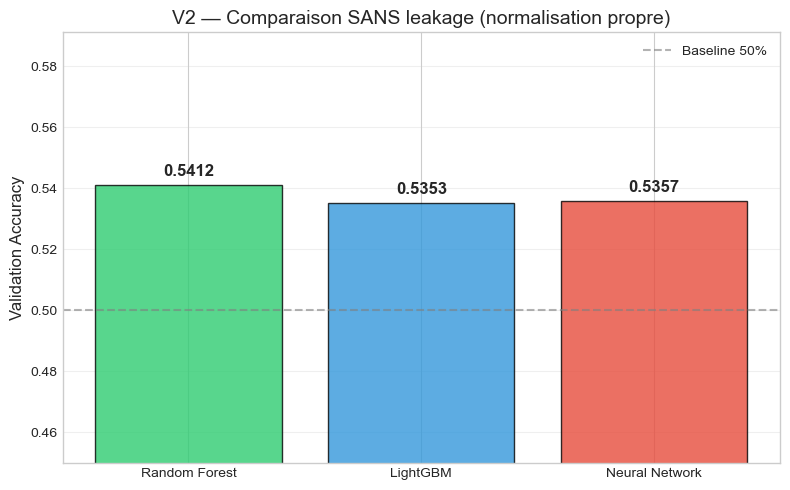


=== Classement ===
  Random Forest        → 0.5412
  Neural Network       → 0.5357
  LightGBM             → 0.5353


In [32]:
results = {
    'Random Forest': rf_val_acc,
    'LightGBM': lgb_val_acc,
    'Neural Network': nn_val_acc,
}

fig, ax = plt.subplots(figsize=(8, 5))
names = list(results.keys())
accs = list(results.values())
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax.bar(names, accs, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Baseline 50%')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', fontweight='bold', fontsize=12)

ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('V2 — Comparaison SANS leakage (normalisation propre)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.45, max(accs) + 0.05)
plt.tight_layout()
plt.savefig('model_comparison_V2_clean.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Classement ===')
for m, a in sorted(results.items(), key=lambda x: -x[1]):
    print(f'  {m:20s} → {a:.4f}')

## Part 8 — Courbes d'entraînement NN

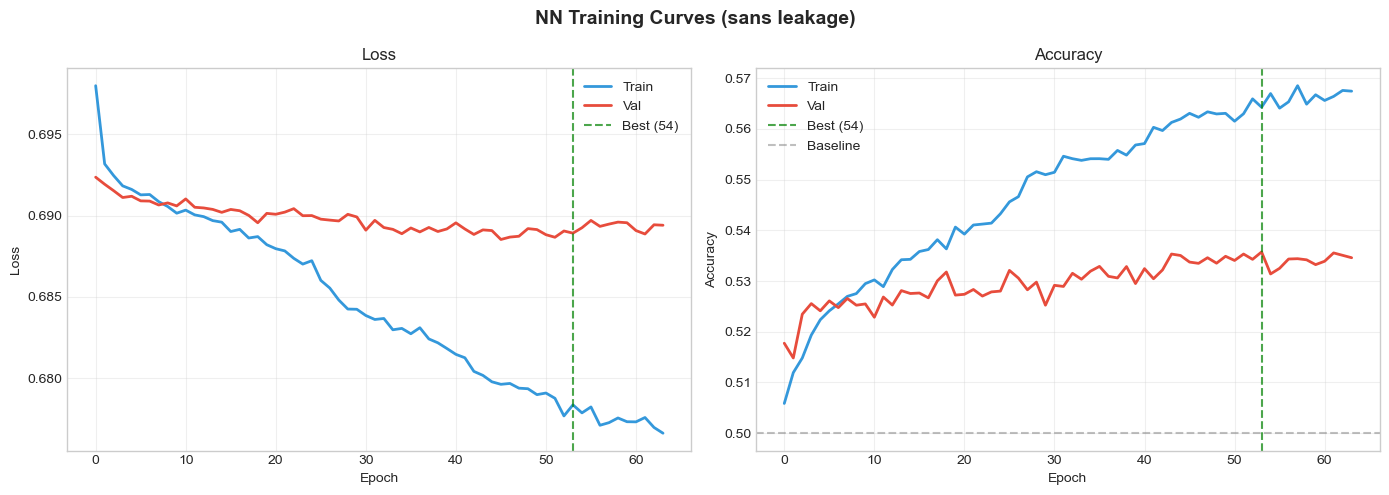

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train', color='#3498db', linewidth=2)
axes[0].plot(history['val_loss'], label='Val', color='#e74c3c', linewidth=2)
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best ({best_epoch+1})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', color='#3498db', linewidth=2)
axes[1].plot(history['val_acc'], label='Val', color='#e74c3c', linewidth=2)
axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best ({best_epoch+1})')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('NN Training Curves (sans leakage)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()